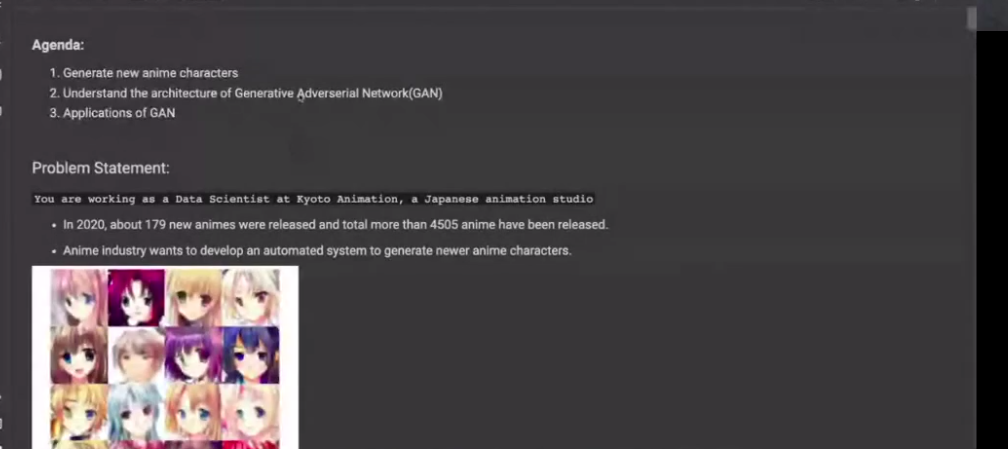

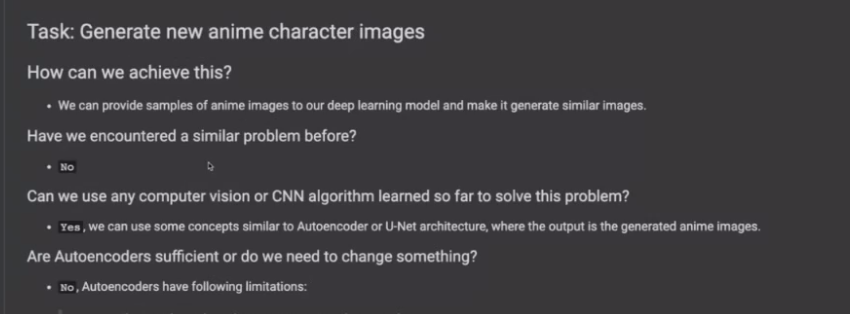

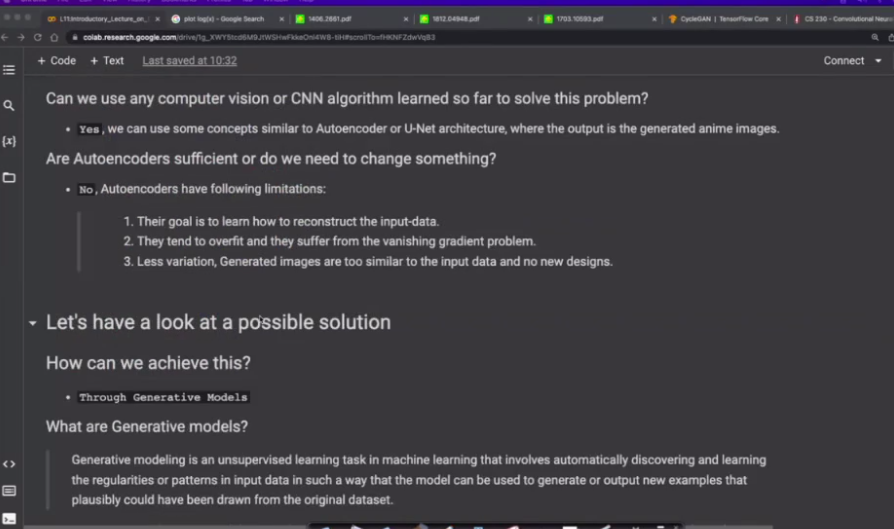

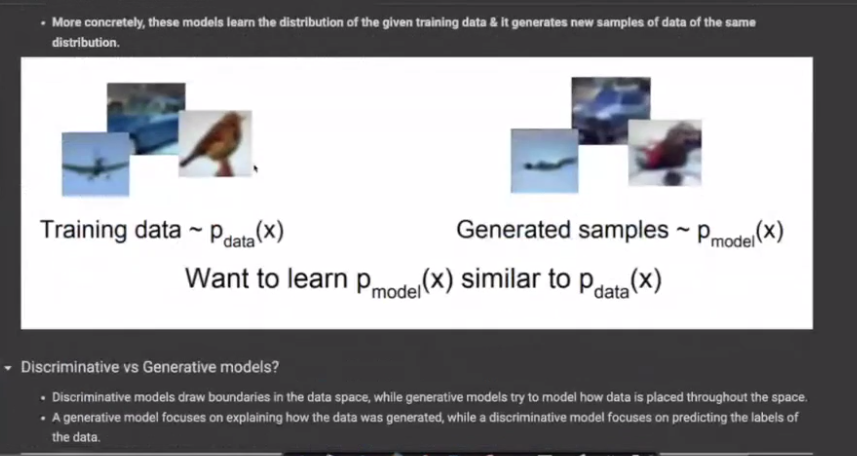

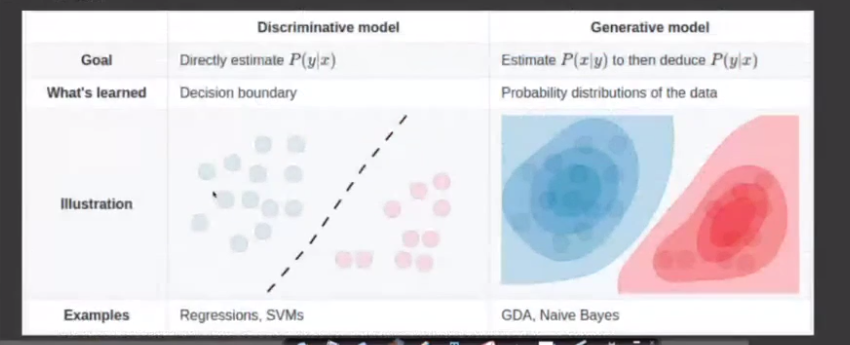

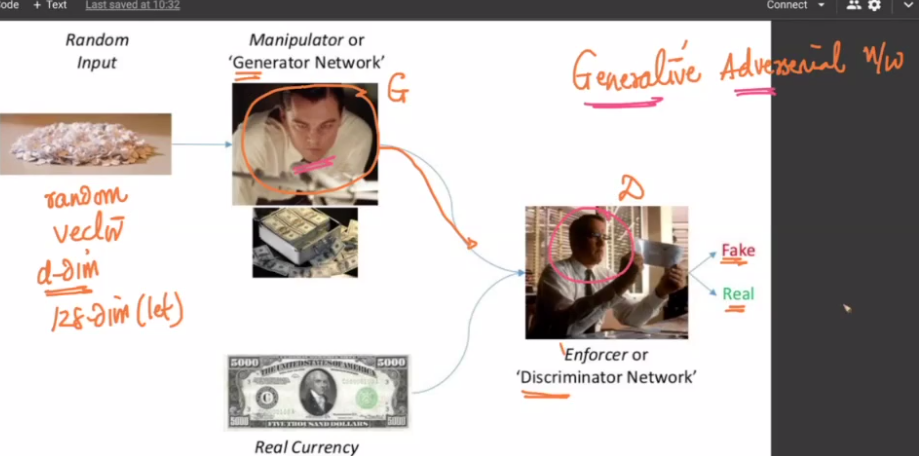

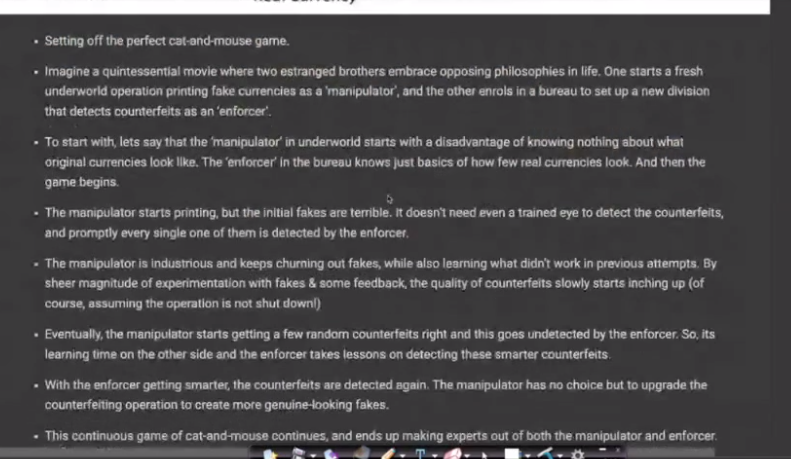

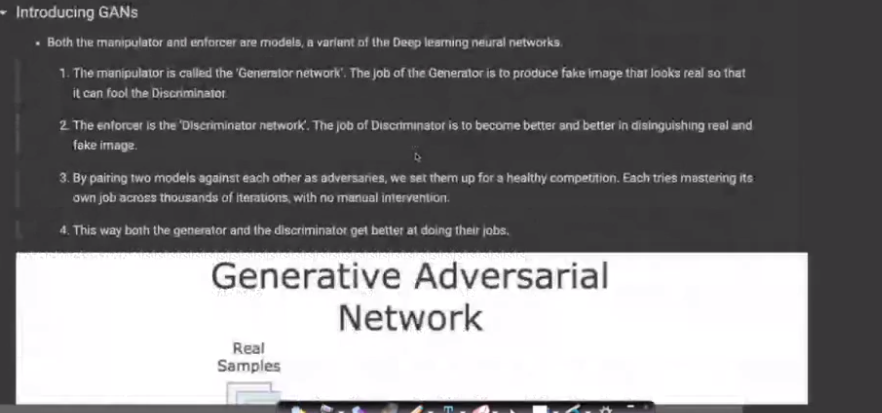

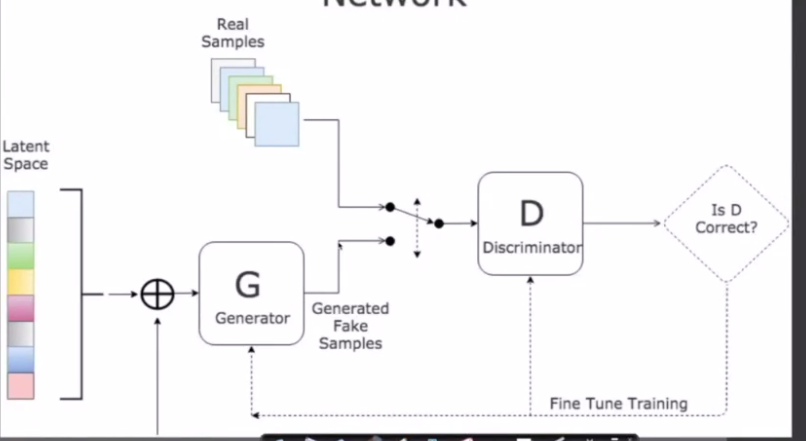

## Generative Adversarial Networks (GANs) in Computer Vision

Generative Adversarial Networks (GANs) are a class of artificial intelligence algorithms used in unsupervised machine learning, implemented by a system of two neural networks contesting with each other in a zero-sum game framework.

First introduced by Ian Goodfellow and his colleagues in 2014, GANs have revolutionized various tasks in computer vision, particularly in generating realistic images.

### How GANs Work: The Adversarial Process

At their core, GANs consist of two main components that are trained simultaneously:

1.  **Generator (G)**: This network learns to generate new data instances that are similar to the real data. Its goal is to fool the discriminator into believing that its generated data is real.
2.  **Discriminator (D)**: This network learns to distinguish between real data (from the training dataset) and fake data (generated by the Generator). Its goal is to correctly identify whether an input is real or fake.

Imagine a scenario with an art forger (Generator) and an art detective (Discriminator):

*   The **Forger** creates fake paintings and tries to make them indistinguishable from real ones.
*   The **Detective** examines paintings, trying to tell if they are originals or fakes.

Both improve over time: the forger gets better at making fakes, and the detective gets better at spotting them. This continuous competition drives both networks to improve, until the generator produces data so realistic that the discriminator can no longer tell the difference.

### Basic GAN Architecture

The training process involves:

1.  **Generator Training**: The Generator takes a random noise vector (often from a latent space) as input and outputs a synthetic data instance (e.g., an image).
2.  **Discriminator Training**: The Discriminator takes both real data samples and the fake data generated by the Generator. It learns to output a probability (between 0 and 1) indicating whether the input is real (close to 1) or fake (close to 0).

The Discriminator is trained to maximize the probability of assigning the correct label to both real and fake samples. The Generator is trained to minimize the probability that the Discriminator will correctly classify its output as fake. This is a minimax game.

### Loss Functions

The objective function for a GAN can be expressed as:

$$ \min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))] $$

Where:
*   $D(x)$ is the Discriminator's estimate of the probability that real data instance $x$ is real.
*   $G(z)$ is the Generator's output when given noise $z$.
*   $D(G(z))$ is the Discriminator's estimate of the probability that a fake instance is real.
*   $\mathbb{E}_{x \sim p_{data}(x)}$ is the expectation over real data instances.
*   $\mathbb{E}_{z \sim p_z(z)}$ is the expectation over noise inputs to the generator.

### Applications of GANs in Computer Vision

GANs have found numerous applications in computer vision:

*   **Realistic Image Generation**: Creating highly realistic images from scratch (e.g., faces of non-existent people).
*   **Image-to-Image Translation**: Converting images from one domain to another (e.g., turning sketches into photos, day to night).
*   **Style Transfer**: Applying the artistic style of one image to the content of another.
*   **Super-Resolution**: Enhancing the resolution of low-resolution images.
*   **Data Augmentation**: Generating synthetic training data to expand datasets, especially useful in cases with limited real data.
*   **Text-to-Image Synthesis**: Generating images directly from textual descriptions.

### Deep Dive: Conditional GANs (cGANs)

While vanilla GANs generate images purely from random noise, Conditional GANs (cGANs) allow for control over the output by providing additional information (e.g., class labels, text descriptions, or other images) to both the Generator and Discriminator. This makes them incredibly powerful for targeted image generation.

For example, a cGAN can generate a specific digit (e.g., '3') if the condition '3' is provided, whereas a vanilla GAN would just generate a random digit.

### Code Example: A Simple GAN for MNIST

Let's implement a basic GAN using TensorFlow/Keras to generate handwritten digits from the MNIST dataset. This example will illustrate the core components: the Generator, the Discriminator, and the training loop.

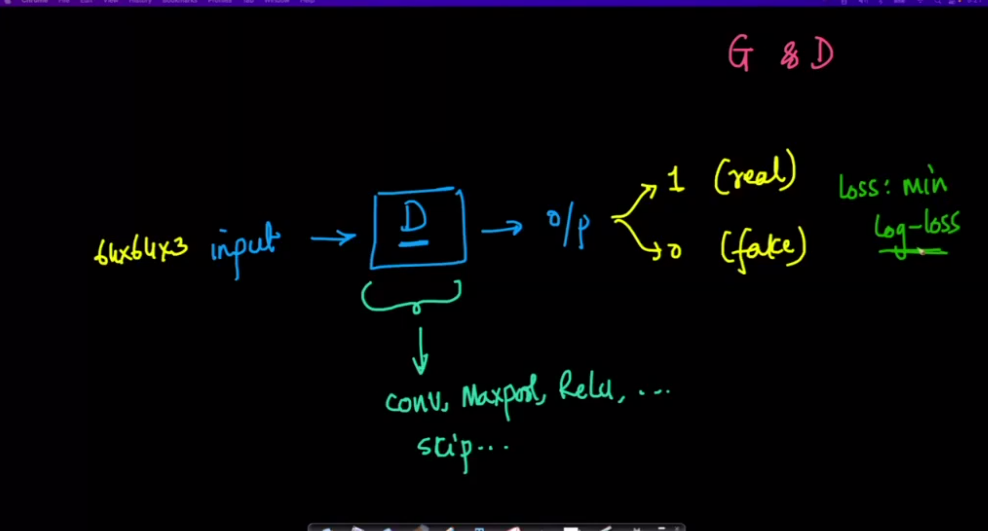

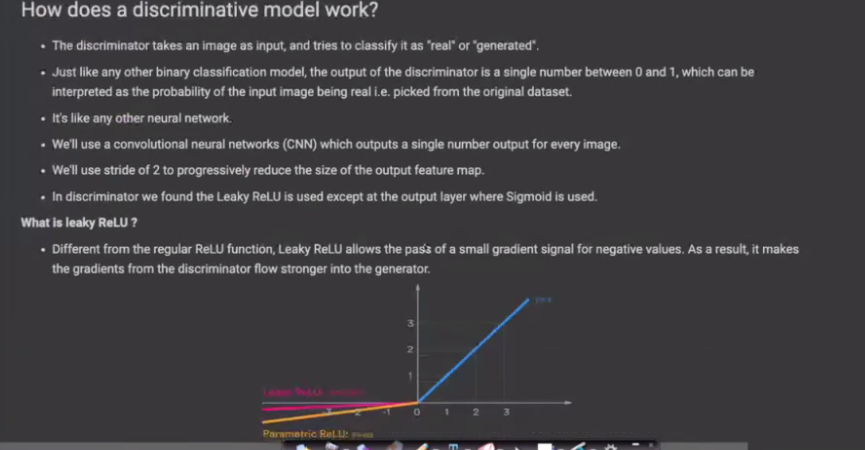

why do we require leakyRELu in descriminator?

ans - it will help the genrator to learn as gradients will flow always from the discriminator

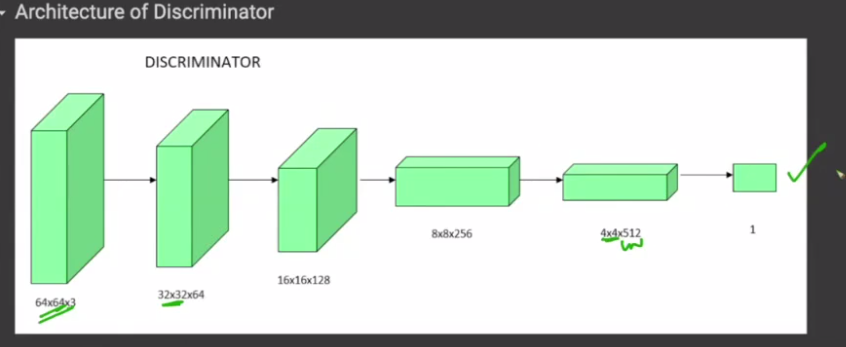

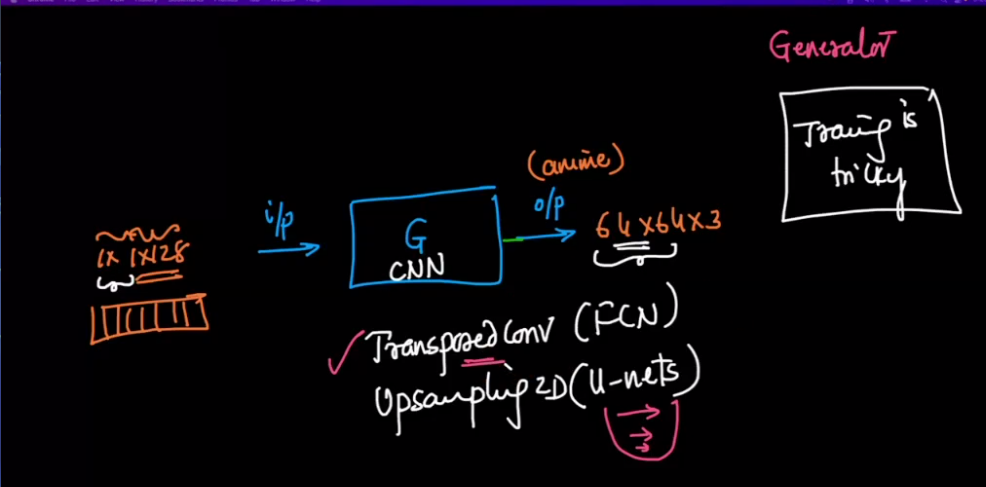

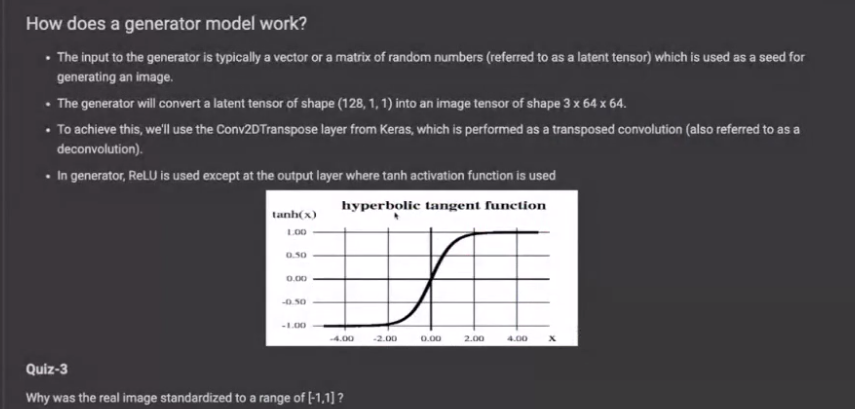

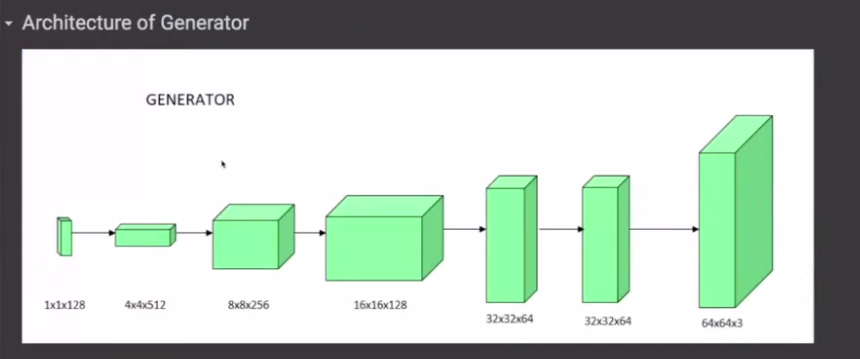

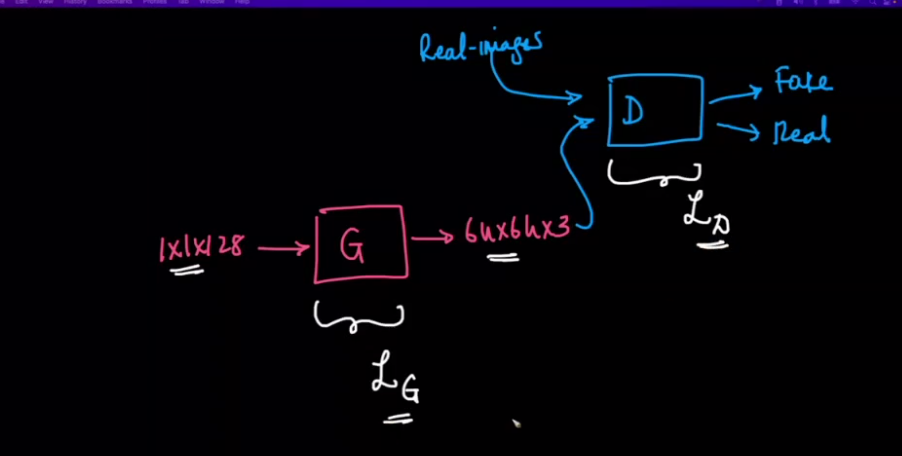

research paper link for GAN - https://arxiv.org/pdf/1406.2661

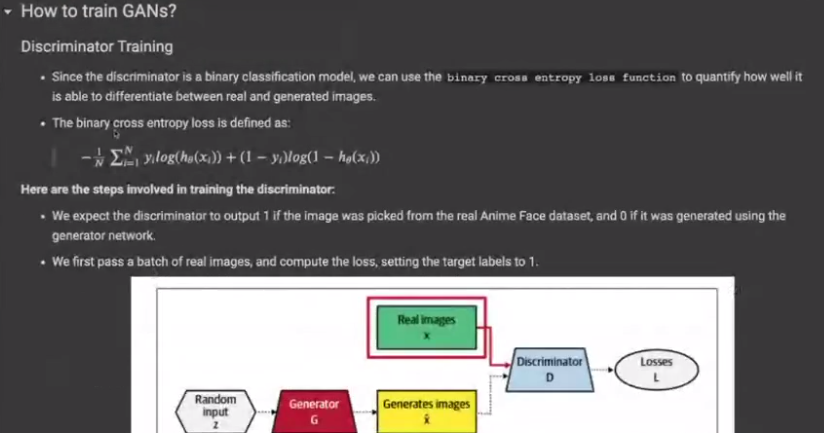

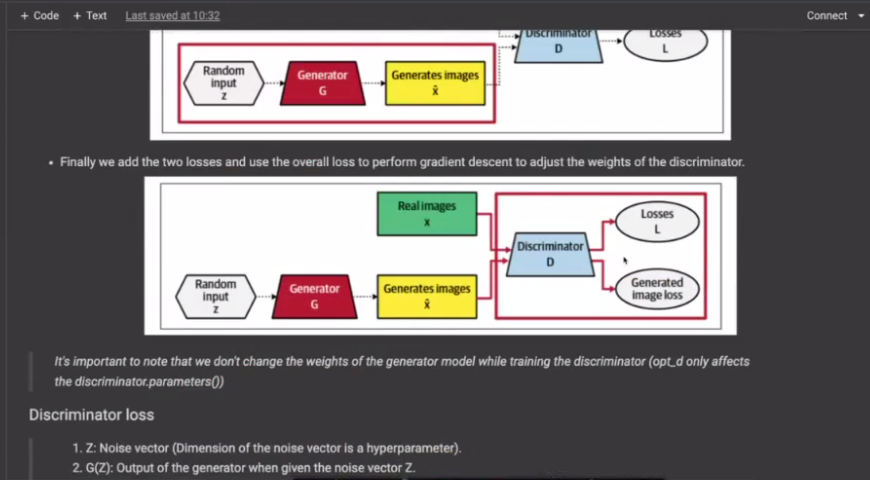

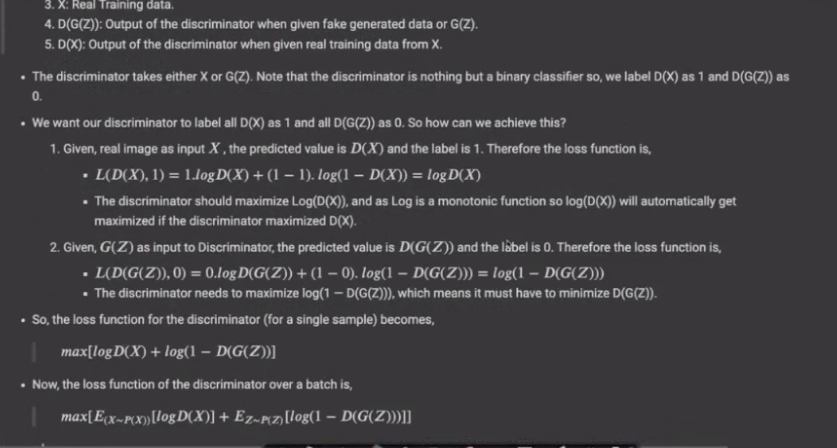

research paper link - https://arxiv.org/pdf/1812.04948

another research paper - https://arxiv.org/pdf/1703.10593

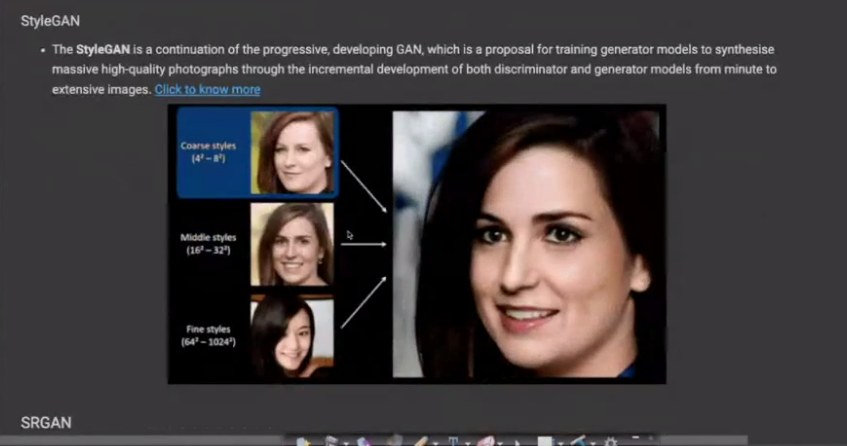

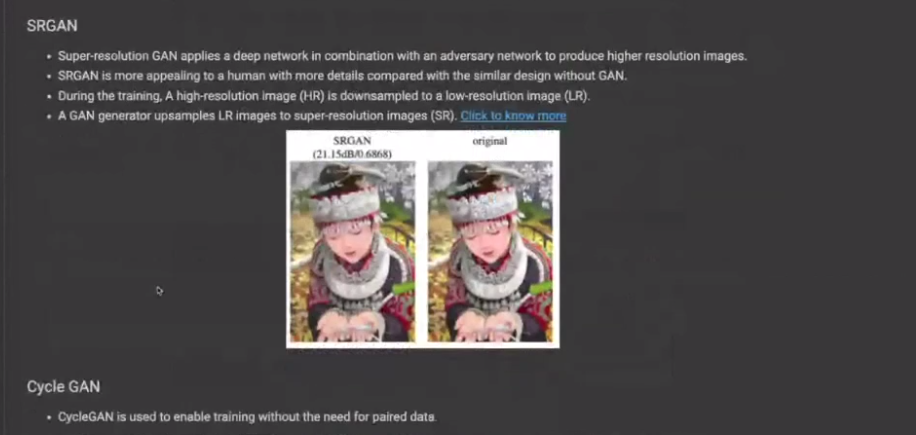

## StyleGAN: Generating High-Resolution and Controllable Images

**StyleGAN** (Style-Based Generator Architecture for Generative Adversarial Networks) is a significant advancement in GAN research, primarily known for generating exceptionally high-quality and realistic images, especially human faces. Developed by NVIDIA, it introduced a novel generator architecture that allows for intuitive, scale-specific control over the synthesis process.

### Key Innovations of StyleGAN:

1.  **Style-Based Generator**: Unlike traditional GANs where latent codes are fed directly into the first layer, StyleGAN introduces the latent code through a *mapping network* that transforms it into an intermediate latent space (W). This W-space is then used to control the 'style' of the image at different resolutions through *adaptive instance normalization (AdaIN)* layers.
2.  **Progressive Growing (inherited from Progressive GANs)**: StyleGAN builds images progressively from low to high resolution. This allows for more stable training and the generation of very high-resolution images.
3.  **Noise Inputs at Each Scale**: Random noise is injected at each convolutional layer of the generator. This allows the generator to create stochastic details (e.g., individual hairs, pores, freckles) independently at different levels of detail, without affecting the high-level attributes.
4.  **Decoupled Style and Content**: The architecture effectively decouples the control of high-level features (like pose, identity, large-scale structures) from low-level features (like colors, textures, fine-grained details). This makes the generated images highly controllable.
5.  **Perceptual Path Length (PPL)**: A metric introduced to quantify the perceptual smoothness of the latent space, helping to improve the interpolation quality between generated images.

### StyleGAN Applications:

*   **Hyper-realistic Face Generation**: StyleGAN is famously used to create entirely new, photorealistic human faces.
*   **Attribute Manipulation**: Users can easily control attributes like age, gender, hair color, and even facial expressions in generated images.
*   **Image Editing**: Tools built on StyleGAN can be used for advanced image editing tasks like image interpolation and style mixing.

## SRGAN: Super-Resolution Using Generative Adversarial Networks

**SRGAN** (Super-Resolution Generative Adversarial Network) is a pioneering work that applied GANs to the problem of **Super-Resolution (SR)**. The goal of super-resolution is to reconstruct a high-resolution (HR) image from a given low-resolution (LR) image. Traditional SR methods often produced blurry results, but SRGAN significantly improved perceptual quality.

### How SRGAN Works:

1.  **Generator (SRResNet)**: The generator network in SRGAN is typically a deep residual network (SRResNet). It takes a low-resolution image as input and upsamples it to the desired high resolution. It tries to learn the mapping from LR to HR images.
2.  **Discriminator**: The discriminator's role is to distinguish between generated super-resolved images and real high-resolution images. It's trained to tell whether an image is a perceptually convincing HR image or an upscaled fake.
3.  **Perceptual Loss**: A crucial innovation of SRGAN is the use of a *perceptual loss function*, which is a combination of:
    *   **Content Loss**: Based on the VGG network, it measures the pixel-wise difference between the feature maps of the reconstructed HR image and the ground-truth HR image. This helps in maintaining high-level content similarity.
    *   **Adversarial Loss**: This is the standard GAN loss, where the generator tries to fool the discriminator. This loss encourages the generator to produce perceptually convincing results rather than just pixel-accurate ones.

By optimizing for perceptual loss, SRGAN can generate images with sharper edges and more realistic textures, even if they are not perfectly pixel-accurate to the original HR image.

### SRGAN Applications:

*   **Image and Video Upscaling**: Significantly improving the visual quality of low-resolution content.
*   **Medical Imaging**: Enhancing details in medical scans.
*   **Surveillance and Security**: Improving the clarity of footage from low-resolution cameras.

## CycleGAN: Unpaired Image-to-Image Translation

**CycleGAN** (Cycle-Consistent Generative Adversarial Network) is a remarkable GAN architecture that enables **image-to-image translation without paired training data**. Traditional image translation tasks (like pix2pix) required corresponding input-output pairs (e.g., a photo and its corresponding segmentation map). CycleGAN broke this barrier.

### How CycleGAN Works:

CycleGAN employs two generator networks ($G_A$ and $G_B$) and two discriminator networks ($D_A$ and $D_B$):

*   **Generator $G_A$**: Translates images from domain A to domain B (e.g., horse to zebra).
*   **Generator $G_B$**: Translates images from domain B to domain A (e.g., zebra to horse).
*   **Discriminator $D_A$**: Distinguishes between real images from domain A and fake images generated by $G_B$.
*   **Discriminator $D_B$**: Distinguishes between real images from domain B and fake images generated by $G_A$.

### Key Innovation: Cycle Consistency Loss

The central idea of CycleGAN is the **cycle consistency loss**. This loss ensures that if an image is translated from one domain to another and then translated back to the original domain, it should be reconstructed to be similar to the original image. This is formulated as:

*   **Forward Cycle Consistency**: $x \to G_A(x) \to G_B(G_A(x)) \approx x$
*   **Backward Cycle Consistency**: $y \to G_B(y) \to G_A(G_B(y)) \approx y$

This cycle consistency constraint allows the networks to learn a meaningful mapping between domains without requiring paired examples.

### CycleGAN Applications:

*   **Style Transfer**: Transforming paintings into photos, or applying different artistic styles.
*   **Season Transfer**: Changing summer scenes to winter scenes and vice-versa.
*   **Object Transfiguration**: Turning horses into zebras or apples into oranges.
*   **Domain Adaptation**: Adapting images from synthetic environments to look like real ones, or vice-versa, for training robustness.

Now that we've covered the theoretical aspects, let's look at how we might set up a simple GAN architecture in code, following the general pattern established by these advanced models.

### 1. Import Necessary Libraries

First, we'll import all the libraries we need. `tensorflow.keras` will be used to build our neural networks, `numpy` for numerical operations, and `matplotlib.pyplot` for plotting our results.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os

# Set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

### 2. Load and Preprocess the MNIST Dataset

We'll use the classic MNIST dataset, which consists of grayscale images of handwritten digits (0-9). The images are 28x28 pixels.

In [2]:
# Load the MNIST dataset directly from Keras
(train_images, train_labels), (_, _) = tf.keras.datasets.mnist.load_data()

# Preprocess the images
# Reshape: Add a channel dimension (28x28 images become 28x28x1 for grayscale)
train_images = train_images.reshape(train_images.shape[0], 28, 28, 1).astype('float32')

# Normalize images to [-1, 1]
# GANs often perform better with this range for tanh activation in the generator output.
# Pixel values are originally 0-255.
train_images = (train_images - 127.5) / 127.5

# Batch and shuffle the data for training
BUFFER_SIZE = 60000 # Size of the dataset
BATCH_SIZE = 256    # Number of images per training batch

train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 3. Define the Generator Model

The Generator's job is to create fake images that look like real MNIST digits. It takes random noise as input and transforms it into an image.

In [3]:
def make_generator_model():
    model = tf.keras.Sequential()

    # Start with a dense layer that takes a random noise vector (e.g., 100 dimensions)
    # and reshapes it into a small 7x7x256 tensor. This effectively 'seeds' the image.
    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization()) # Stabilizes learning by normalizing inputs to each layer
    model.add(layers.LeakyReLU())          # An activation function that allows small negative values (helps prevent 'dying neurons')

    model.add(layers.Reshape((7, 7, 256))) # Reshape the output to a 3D tensor
    assert model.output_shape == (None, 7, 7, 256) # None indicates batch size

    # Upsampling block 1: Increases resolution from 7x7 to 14x14
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsampling block 2: Increases resolution from 14x14 to 28x28
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Output layer: Produces a 28x28x1 grayscale image
    # The tanh activation scales pixel values to [-1, 1], matching our input data normalization.
    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


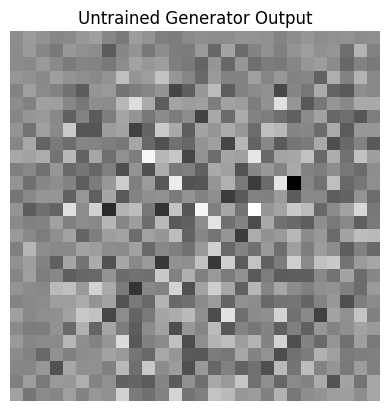

In [4]:
# Create an instance of the generator
generator = make_generator_model()

# Generate a random noise input
noise = tf.random.normal([1, 100]) # 1 image, 100 dimensions of noise

# Get the generated image from the generator
generated_image = generator(noise, training=False) # training=False because we are just doing inference

# Visualize the initial, untrained generated image
plt.imshow(generated_image[0, :, :, 0], cmap='gray')
plt.title("Untrained Generator Output")
plt.axis('off')
plt.show()

### 4. Define the Discriminator Model

The Discriminator's role is to tell whether an input image is real (from the MNIST dataset) or fake (generated by our Generator). It outputs a single probability value.

In [5]:
def make_discriminator_model():
    model = tf.keras.Sequential()

    # Convolutional block 1: Takes a 28x28x1 image, applies filters, and downsamples to 14x14
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[28, 28, 1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3)) # Randomly sets a fraction of input units to 0 at each update during training (helps prevent overfitting)

    # Convolutional block 2: Downsamples to 7x7
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten the output to feed into a dense layer
    model.add(layers.Flatten())

    # Output layer: A single neuron with sigmoid activation to output a probability (0 for fake, 1 for real)
    model.add(layers.Dense(1, activation='sigmoid')) # Sigmoid for binary classification probability

    return model

In [6]:
# Create an instance of the discriminator
discriminator = make_discriminator_model()

# Evaluate the discriminator on the untrained generated image
decision = discriminator(generated_image) # Should output a value close to 0.5 (random guess)
print(f"Discriminator's initial decision on fake image: {decision.numpy()}")

# Get a batch of real images
for image_batch in train_dataset.take(1):
    real_images_sample = image_batch

# Evaluate the discriminator on a real image
decision_real = discriminator(real_images_sample)
print(f"Discriminator's initial decision on real images: {decision_real.numpy()[0]} (first image in batch)")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Discriminator's initial decision on fake image: [[0.5000465]]
Discriminator's initial decision on real images: [0.4727877] (first image in batch)


### 5. Define Loss Functions and Optimizers

GANs use a unique training strategy where both networks have their own loss functions and optimizers. We'll use `BinaryCrossentropy` because this is a binary classification problem for the discriminator (real or fake).

In [7]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False) # from_logits=False because our discriminator output has sigmoid activation

def discriminator_loss(real_output, fake_output):
    # Loss for real images: Compare discriminator's output for real images to an array of 1s (indicating real)
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    # Loss for fake images: Compare discriminator's output for fake images to an array of 0s (indicating fake)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    # Total discriminator loss is the sum of these two
    total_loss = real_loss + fake_loss
    return total_loss

def generator_loss(fake_output):
    # The generator wants the discriminator to output 1s (i.e., believe the fake images are real)
    # So, we compare the discriminator's output for fake images to an array of 1s.
    return cross_entropy(tf.ones_like(fake_output), fake_output)

# Optimizers for each network. Adam is a popular choice for GANs.
generator_optimizer = tf.keras.optimizers.Adam(1e-4) # Learning rate of 0.0001
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

### 6. Training Loop

The training loop is the heart of the GAN. In each step, we train the discriminator and then the generator. The key is to alternate their training, letting them learn from each other.

Starting epoch 1/30


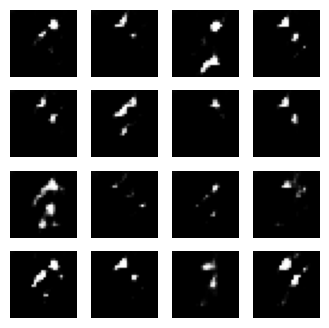

Starting epoch 2/30


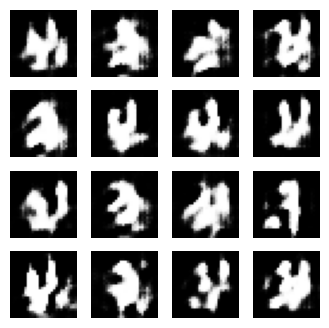

Starting epoch 3/30


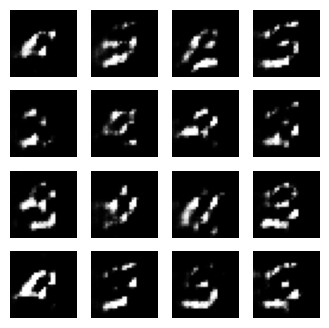

Starting epoch 4/30


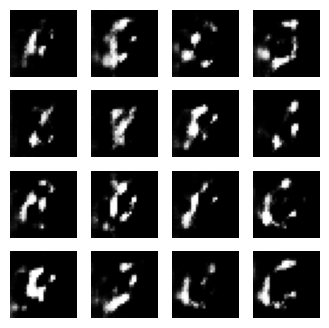

Starting epoch 5/30


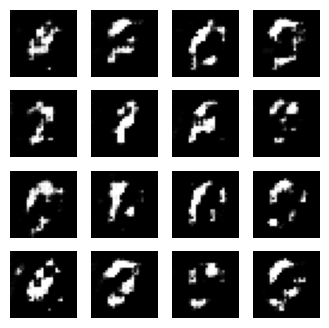

Starting epoch 6/30


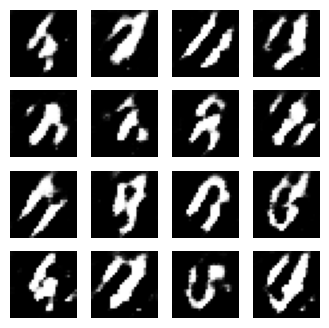

Starting epoch 7/30


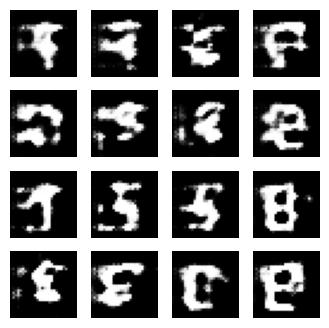

Starting epoch 8/30


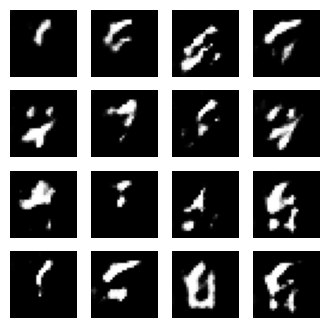

Starting epoch 9/30


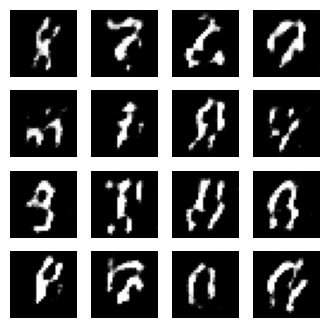

Starting epoch 10/30


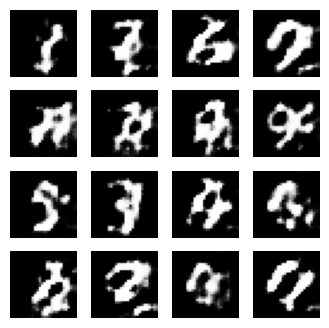

Starting epoch 11/30


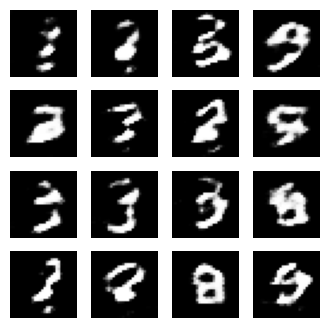

Starting epoch 12/30


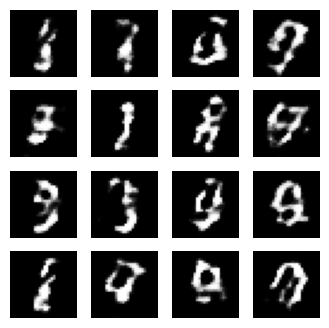

Starting epoch 13/30


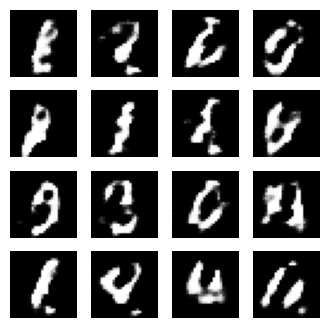

Starting epoch 14/30


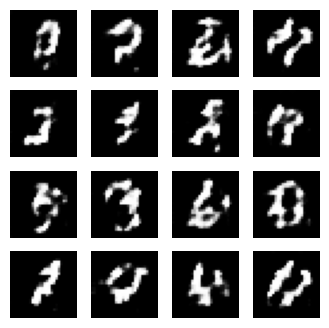

Starting epoch 15/30


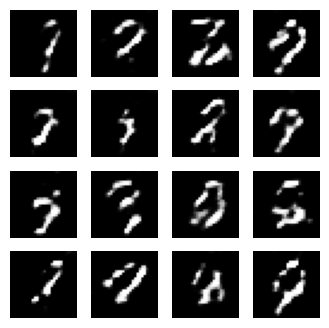

Starting epoch 16/30


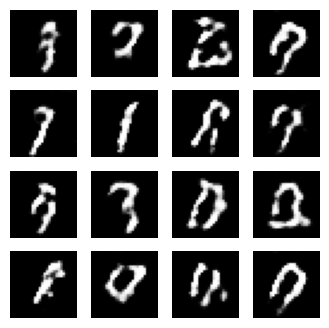

Starting epoch 17/30


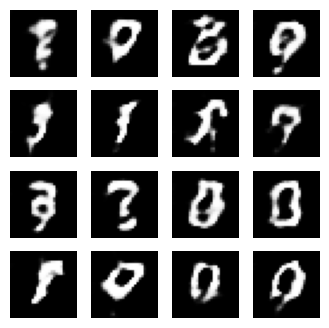

Starting epoch 18/30


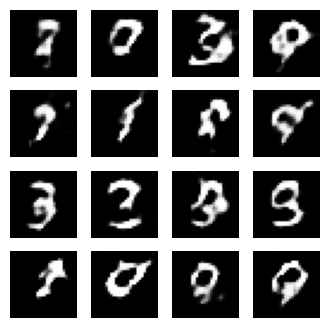

Starting epoch 19/30


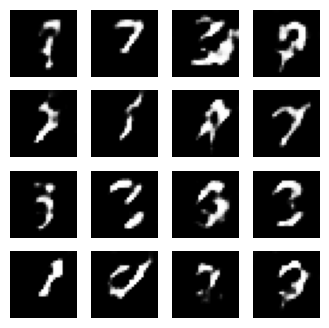

Starting epoch 20/30


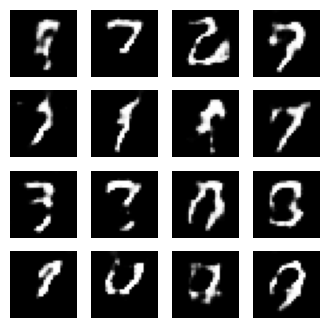

Starting epoch 21/30


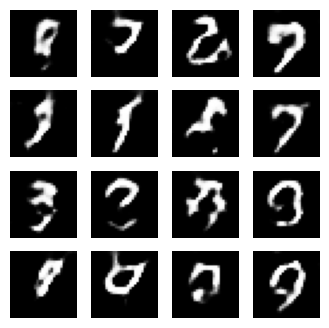

Starting epoch 22/30


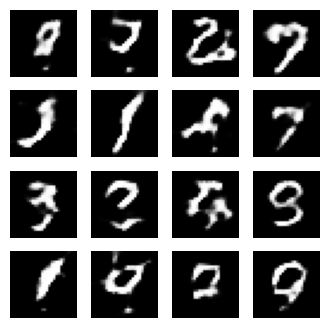

Starting epoch 23/30


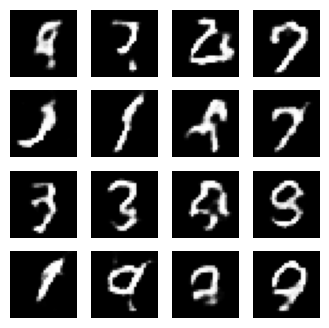

Starting epoch 24/30


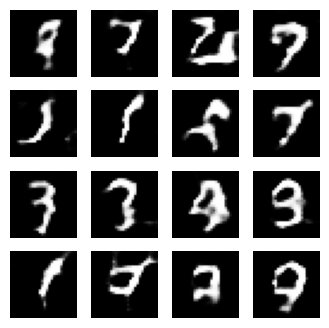

Starting epoch 25/30


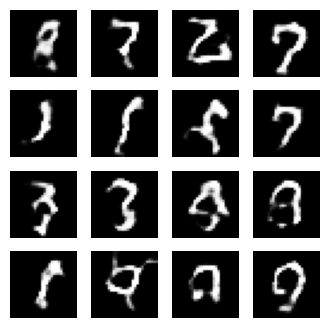

Starting epoch 26/30


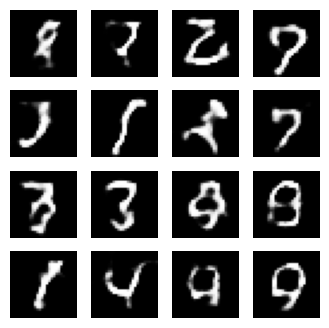

Starting epoch 27/30


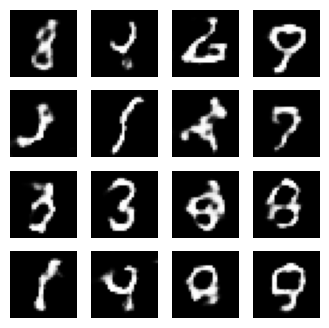

Starting epoch 28/30


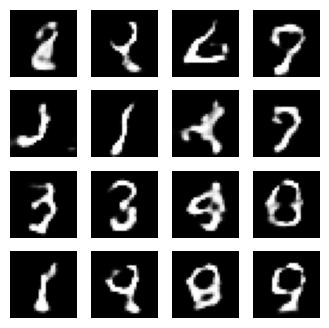

Starting epoch 29/30


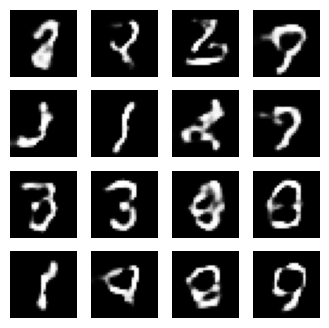

Starting epoch 30/30


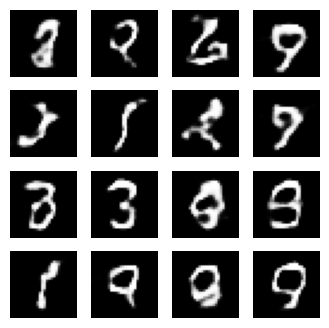

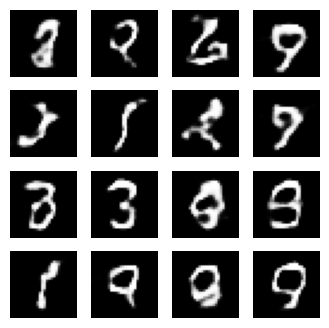

In [9]:
EPOCHS = 30       # Number of times to iterate over the entire dataset
noise_dim = 100   # Dimension of the random noise input to the generator
num_examples_to_generate = 16 # Number of images to generate and display at the end of each epoch

# This seed will be reused to visualize progress of the generator over time
seed = tf.random.normal([num_examples_to_generate, noise_dim])

# `tf.function` compiles a Python function into a callable TensorFlow graph.
# This greatly speeds up training.
@tf.function
def train_step(images):
    # Generate random noise for the generator input
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    # Use tf.GradientTape to record operations for automatic differentiation
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generator creates fake images
        generated_images = generator(noise, training=True)

        # Discriminator classifies real images and fake images
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Calculate loss for both networks
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Compute gradients for each network
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    # Apply gradients to update network weights
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

def generate_and_save_images(model, epoch, test_input):
    # Notice `training` is set to False. This is so all layers run in inference mode (e.g. BatchNormalization).
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        # Scale image pixels back to 0-1 range for display (from -1 to 1)
        plt.imshow((predictions[i, :, :, 0] + 1) / 2, cmap='gray')
        plt.axis('off')

    # Save the generated images for later review
    plt.savefig(os.path.join('.', 'generated_images', f'image_at_epoch_{epoch:04d}.png'))
    plt.show()

def train(dataset, epochs):
    # Create a directory to save generated images
    if not os.path.exists('./generated_images'):
        os.makedirs('./generated_images')

    for epoch in range(epochs):
        print(f"Starting epoch {epoch+1}/{epochs}")
        for image_batch in dataset:
            train_step(image_batch)

        # Produce images for the GIF as we go
        # This happens at the end of each epoch to show progress
        generate_and_save_images(generator, epoch + 1, seed)

    # Generate after the final epoch
    generate_and_save_images(generator, epochs, seed)


# Start the training!
train(train_dataset, EPOCHS)

### Explanation of the Training Process:

1.  **Noise Input**: For each training step, a batch of random noise vectors is generated and fed into the Generator.
2.  **Generate Fake Images**: The Generator uses this noise to produce a batch of fake images.
3.  **Discriminator Evaluation**: The Discriminator is then fed both the real images (from the MNIST dataset) and the fake images (from the Generator).
4.  **Calculate Losses**:
    *   **Discriminator Loss**: It calculates how well it distinguished between real and fake images. It wants to output `1` for real images and `0` for fake images. If it fails, its loss increases.
    *   **Generator Loss**: It calculates how well it *fooled* the discriminator. It wants the discriminator to output `1` (real) for its fake images. If the discriminator outputs `0` (fake), the generator's loss increases.
5.  **Compute and Apply Gradients**: Using `tf.GradientTape`, the gradients of the losses with respect to each network's trainable variables are computed. These gradients are then used by the Adam optimizers to update the weights of the Generator and Discriminator, respectively.
6.  **Alternating Updates**: Crucially, the Generator's weights are updated to make its fake images more convincing, while the Discriminator's weights are updated to make it better at distinguishing real from fake. This adversarial process drives both networks to improve.

### What to Observe and Next Steps:

As the training progresses, you should see the generated images become more and more like actual handwritten digits. Early on, they will just be noise. Over time, they will start to form recognizable shapes.

This is a basic GAN. To get better results, you could:
*   Train for more epochs.
*   Experiment with different network architectures (more layers, different filter sizes).
*   Adjust learning rates or use different optimizers.
*   Explore more advanced GAN techniques like DCGAN, WGAN, or the StyleGAN, SRGAN, and CycleGAN we discussed earlier!